In [1]:
import sys
import os 
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("../"))
from simulators.CellularAutomaton import CellularAutomaton

# **Examples**

In [2]:
# Example of a height update function that could be used in the model
def height_update(x):
        if x <= 0:
            return np.exp(x)
        else:
            return 1 + np.sqrt(x)/10 
    

## 1 : No wind no topography

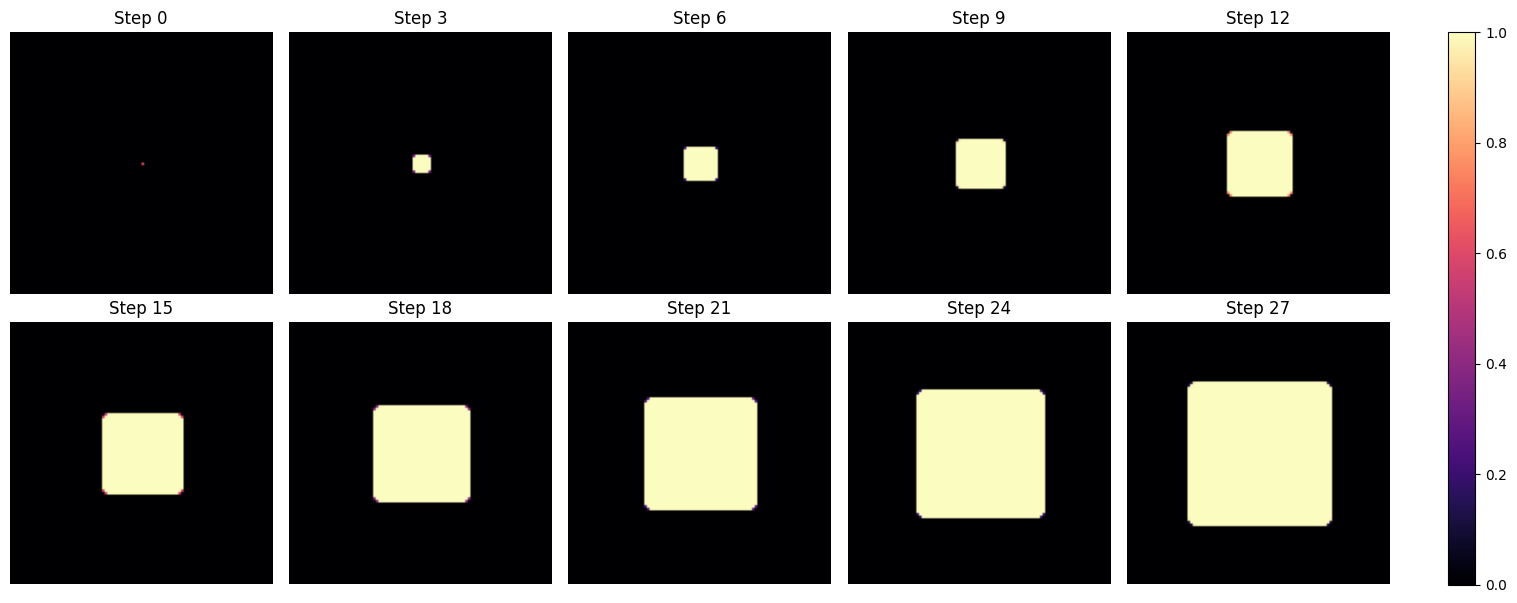

In [3]:
N=100

wind = np.ones((N, N))
heights = np.zeros((N, N))

CA = CellularAutomaton(N, N, wind, heights, height_update)

CA.initialize_ignition([(N//2, N//2)], [0.6])

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
plot_idx = 0

steps=30
for step in range(steps):
    if step % (steps//10) == 0 and plot_idx < 10:
        current_state = CA.get_state()
        im = axes[plot_idx].imshow(current_state, vmin=0, vmax=1, cmap='magma')
        axes[plot_idx].set_title(f"Step {step}")
        axes[plot_idx].axis('off')
        plot_idx += 1

    CA.evolve()

plt.tight_layout()
plt.colorbar(im, ax=axes.ravel().tolist(), fraction=0.02, pad=0.04)
plt.show()

Text(0.5, 1.0, 'Fire Spread Over Time')

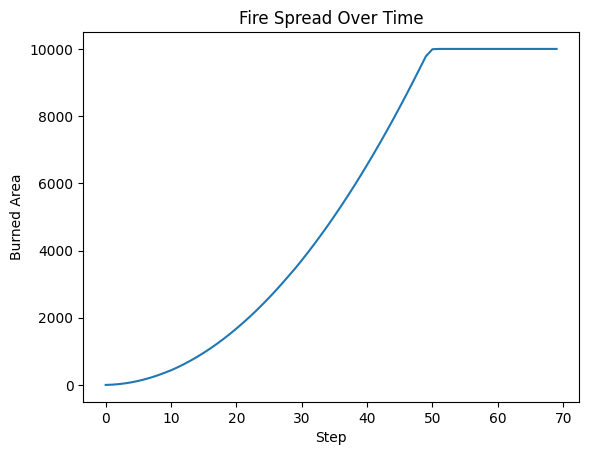

In [4]:
burned_area = []

wind = np.ones((N, N))
heights = np.zeros((N, N))

CA = CellularAutomaton(N, N, wind, heights, height_update)

CA.initialize_ignition([(N//2, N//2)], [0.6])


for step in range(70):
    burned_area.append(np.sum(CA.get_state() > 0.1))
    CA.evolve()

plt.plot(burned_area)
plt.xlabel("Step")
plt.ylabel("Burned Area")
plt.title("Fire Spread Over Time")

### 2 : Adding gradient/slope

In [ ]:
# Example of a height update function that could be used in the model
def height_update(x):
        if x <= 0:
            return np.exp(x)
        else:
            return 1 + np.sqrt(x)/10    

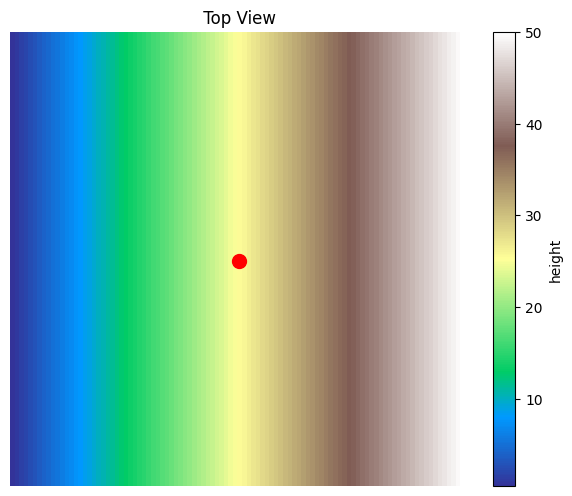

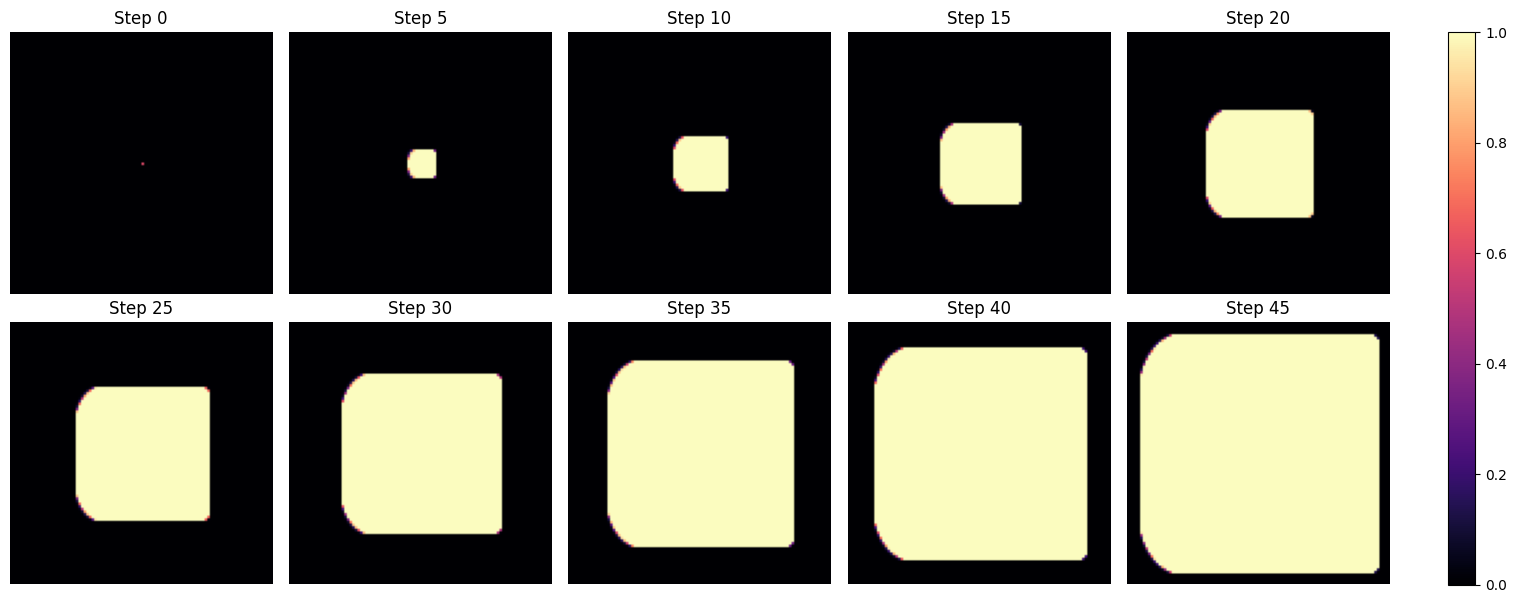

In [5]:
N=100

wind = np.ones((N, N))
# Linearly increasing heights from left to right to create a linear slope
heights = np.hstack([(k/2)*np.ones((N, 1)) for k in range(1, N+1)])

plt.figure(figsize=(6, 5))
plt.scatter(N//2, N//2, color='red', s=100, zorder=5, label="Initial Ignition Point")
im = plt.imshow(heights, cmap='terrain', origin='upper')
plt.title(" Top View")
plt.axis('off')
plt.colorbar(im, label="height")
plt.tight_layout()
plt.show()

CA = CellularAutomaton(N, N, wind, heights, height_update)

CA.initialize_ignition([(N//2, N//2)], [0.6])

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
plot_idx = 0


n=50
for step in range(n):
    if step % (n // 10) == 0 and plot_idx < 10:
        current_state = CA.get_state()
        im = axes[plot_idx].imshow(current_state, vmin=0, vmax=1, cmap='magma')
        axes[plot_idx].set_title(f"Step {step}")
        axes[plot_idx].axis('off')
        plot_idx += 1

    
    CA.evolve()

plt.tight_layout()
plt.colorbar(im, ax=axes.ravel().tolist(), fraction=0.02, pad=0.04)
plt.show() 

We should expect to see an accelerated fire spread to the right, and that is indeed the case. Moreover, the propgation is symmetrical at the bottom, so it’s consistent!

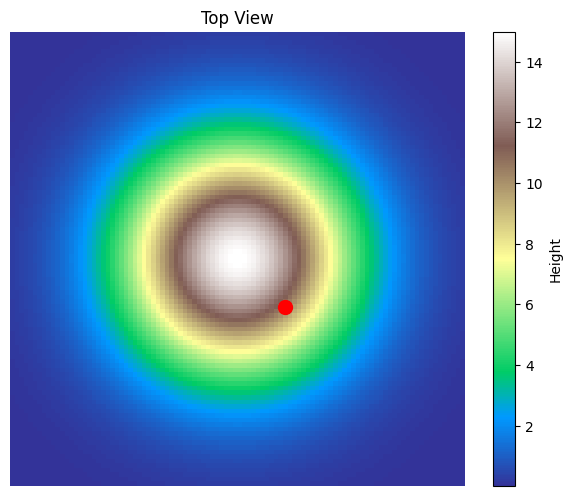

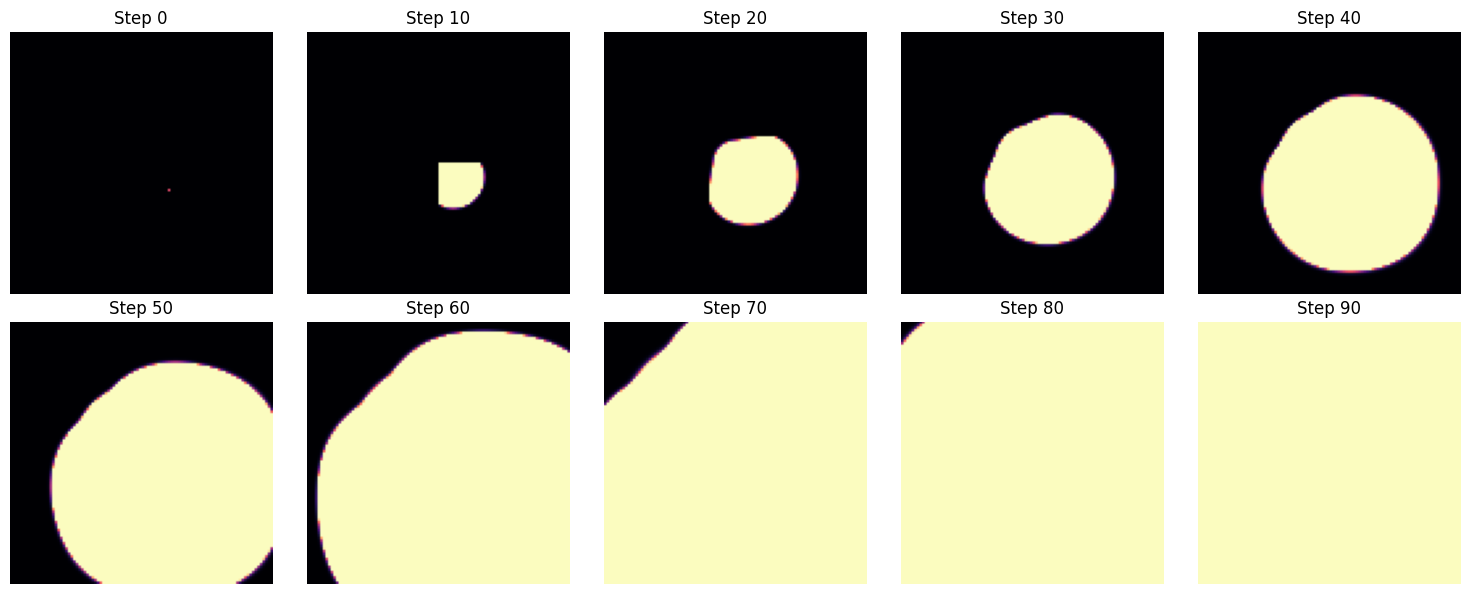

In [6]:
# Now let's create a more complex terrain with a mountain in the center
x, y = np.meshgrid(np.linspace(-2, 2, 100), np.linspace(-2, 2, 100))
heights = 15 * np.exp(-(x**2 + y**2)) # Sommet au centre
plt.figure(figsize=(6, 5))
im = plt.imshow(heights, cmap='terrain', origin='upper')
plt.scatter(60, 60, color='red', s=100, zorder=5, label="Initial Ignition Point")
plt.title("Top View")
plt.axis('off')
plt.colorbar(im, label="Height")
plt.tight_layout()
plt.show()


# We can also test a different height update function to see how it affects the fire spread :
def height_update_2(delta_h):
    return np.exp(6.0 * delta_h)
wind = np.ones((100, 100))

CA = CellularAutomaton(100, 100, np.ones((100, 100)), heights, height_update_2)
CA.initialize_ignition([(60, 60)], [0.6]) 


fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
plot_idx = 0

for step in range(101):
    if step % 10 == 0 and plot_idx < 10:
        current_state = CA.get_state()
        axes[plot_idx].imshow(current_state, vmin=0, vmax=1, cmap='magma')
        axes[plot_idx].set_title(f"Step {step}")
        axes[plot_idx].axis('off')
        plot_idx += 1
    CA.evolve()

plt.tight_layout()
plt.show()

We notice that the result is once again very consistent because the terrain is a centered Gaussian mountain. The light starts at the bottom right. We notice that it spreads faster in the climb (step 10). Then, once it has reached the top of the hill, it spreads more slowly because we are in the downhill. Regarding at the bottom right, once it reaches the bottom of the hill, it spreads faster.

Impact of the $\phi$ function on fire spread in a linear slope

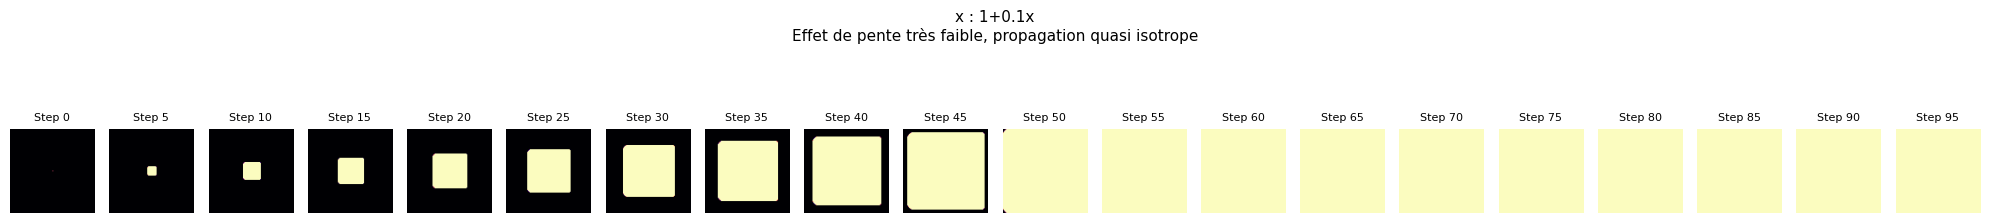

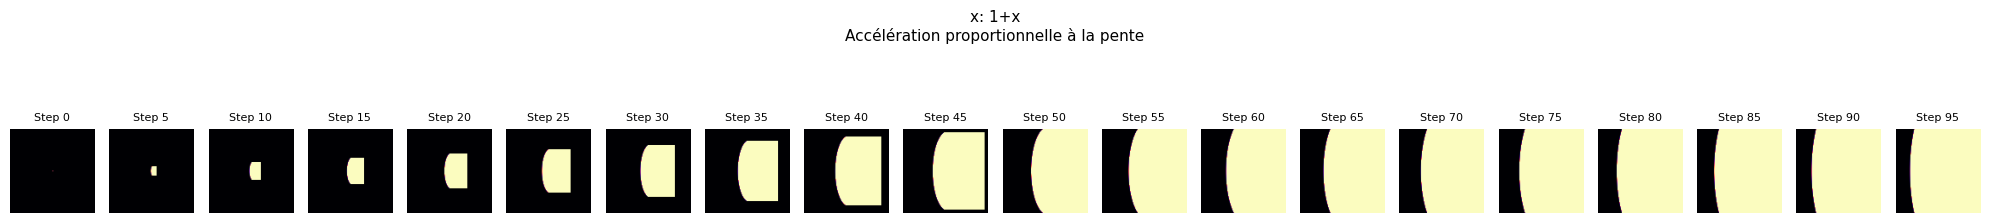

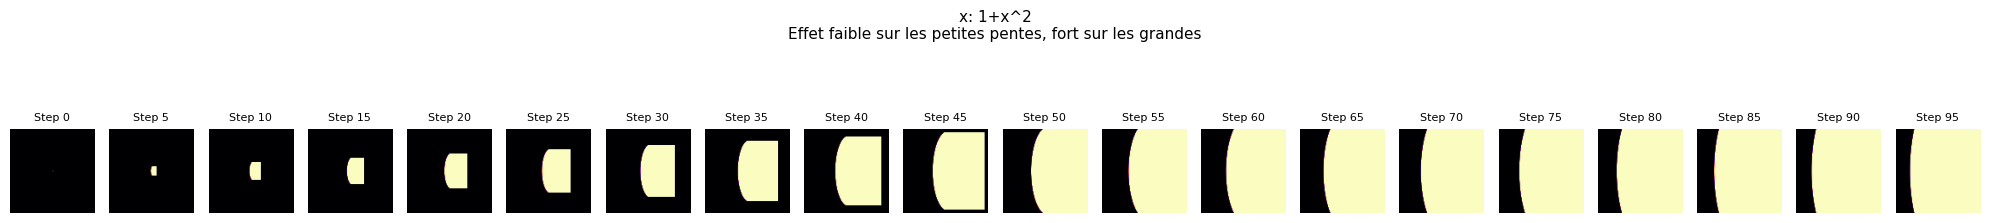

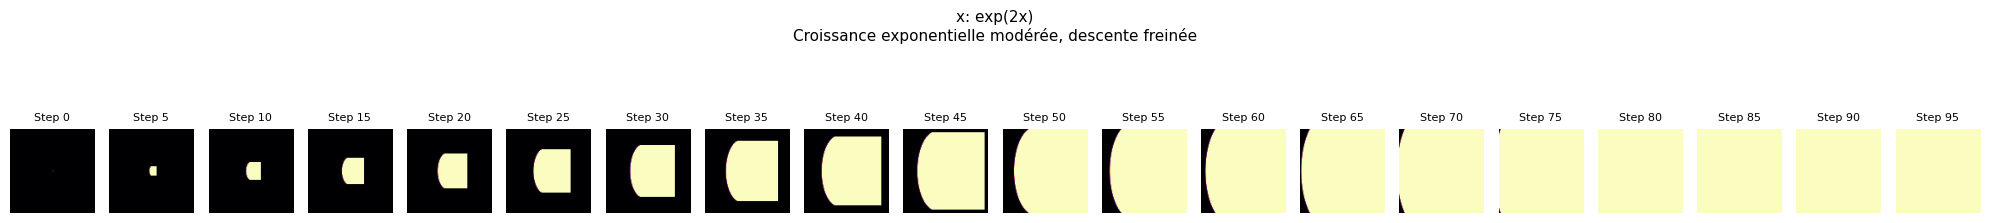

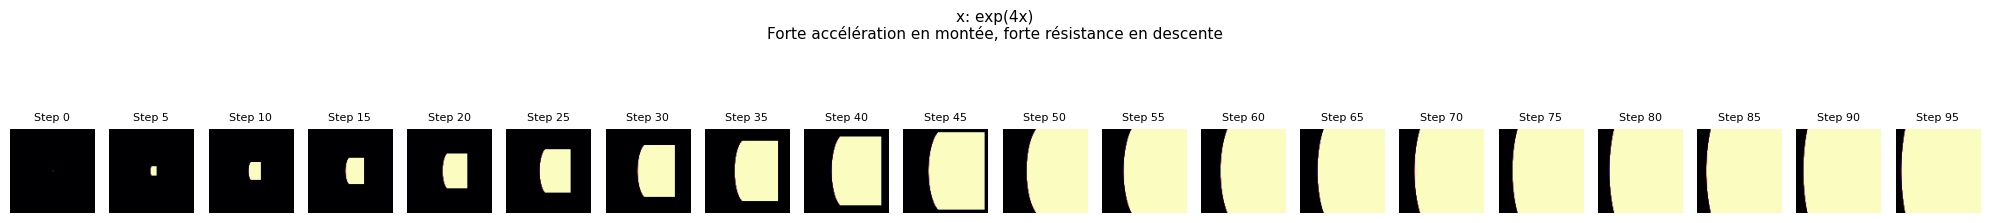

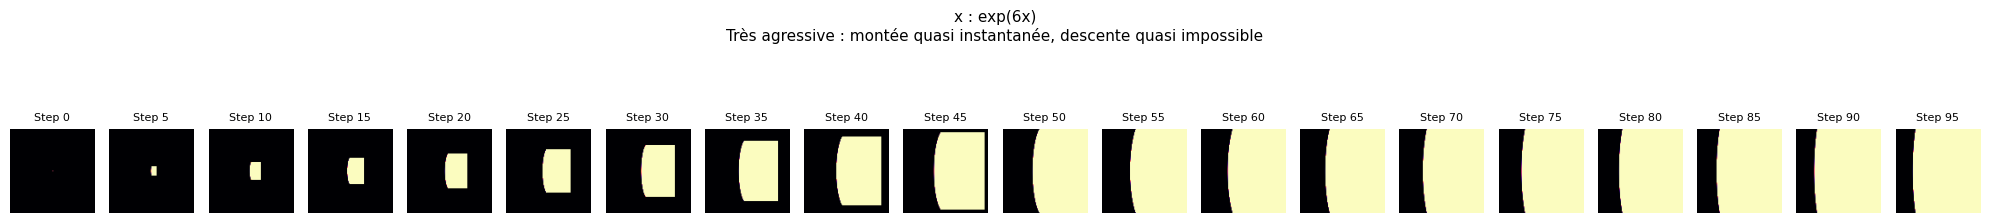

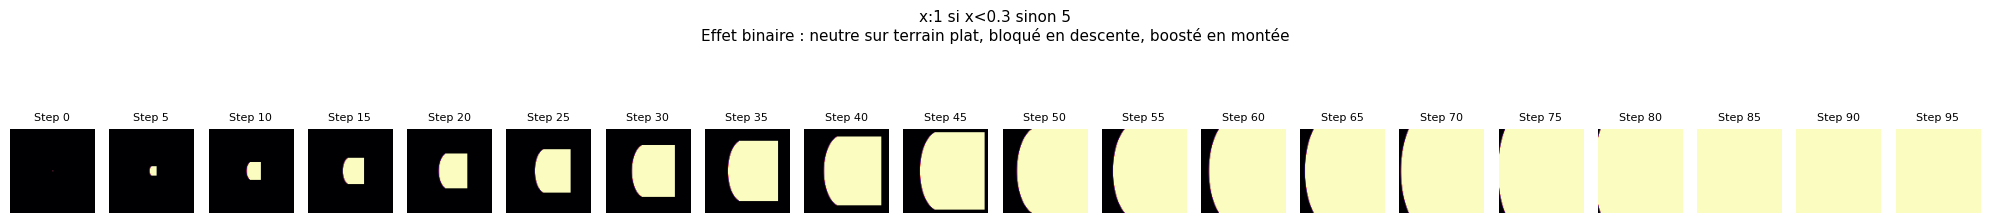

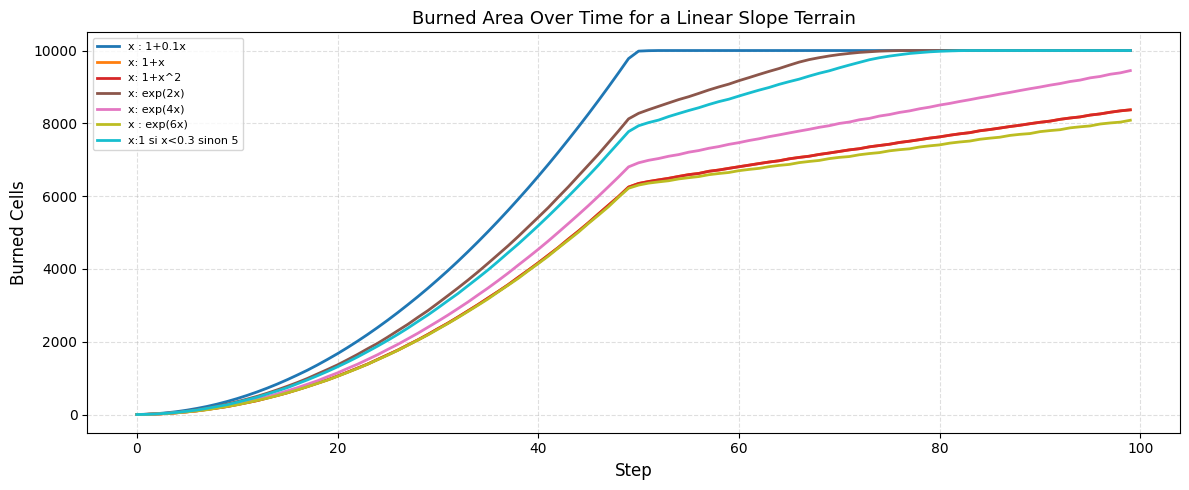

In [11]:
# Different height update functions to test
phi_functions = {
    "x : 1+0.1x": {
        "fn": lambda x: max(0.01, 1 + 0.1 * x),
        "desc": "Effet de pente très faible, propagation quasi isotrope"
    },
    "x: 1+x": {
        "fn": lambda x: max(0.01, 1 + x),
        "desc": "Accélération proportionnelle à la pente"
    },
    "x: 1+x^2": {
        "fn": lambda x: max(0.01, 1 + x**2 * np.sign(x)),
        "desc": "Effet faible sur les petites pentes, fort sur les grandes"
    },
    "x: exp(2x)": {
        "fn": lambda x: np.exp(2.0 * x),
        "desc": "Croissance exponentielle modérée, descente freinée"
    },
    "x: exp(4x)": {
        "fn": lambda x: np.exp(4.0 * x),
        "desc": "Forte accélération en montée, forte résistance en descente"
    },
    "x : exp(6x)": {
        "fn": lambda x: np.exp(6.0 * x),
        "desc": "Très agressive : montée quasi instantanée, descente quasi impossible"
    },
    "x:1 si x<0.3 sinon 5": {
        "fn": lambda x: 0.1 if x < -0.3 else (1.0 if abs(x) <= 0.3 else 5.0),
        "desc": "Effet binaire : neutre sur terrain plat, bloqué en descente, boosté en montée"
    },
}

# Parameters for the simulation
heights = np.hstack([k * np.ones((100, 1)) for k in range(1, 101)])
wind    = np.ones((100, 100))

n_steps       = 20
step_interval = 5
total_steps   = n_steps * step_interval

burned_histories = {}

for name, entry in phi_functions.items():
    phi  = entry["fn"]
    desc = entry["desc"]

    CA = CellularAutomaton(100, 100, wind, heights, phi)
    CA.initialize_ignition([(50, 50)], [0.6])

    burned    = []
    plot_idx  = 0
    snapshots = []

    for step in range(total_steps):
        burned.append(np.sum(CA.get_state() > 0.1))
        if step % step_interval == 0 and plot_idx < n_steps:
            snapshots.append((step, CA.get_state().copy()))
            plot_idx += 1
        CA.evolve()

    burned_histories[name] = burned

    fig, axes = plt.subplots(1, n_steps, figsize=(20, 2.5))
    for ax, (step, state) in zip(axes, snapshots):
        im = ax.imshow(state, vmin=0, vmax=1, cmap='magma')
        ax.set_title(f"Step {step}", fontsize=8)
        ax.axis('off')

    short_name = name.replace("\n", " — ")
    fig.suptitle(f"{short_name}\n{desc}", fontsize=11, y=1.05)
    #plt.colorbar(im, ax=axes.tolist(), fraction=0.02, pad=0.04)
    plt.tight_layout()
    plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(phi_functions)))

for (name, burned), color in zip(burned_histories.items(), colors):
    ax.plot(burned, label=name, linewidth=2, color=color)

ax.set_xlabel("Step", fontsize=12)
ax.set_ylabel("Burned Cells", fontsize=12)
ax.set_title("Burned Area Over Time for a Linear Slope Terrain", fontsize=13)
ax.legend(fontsize=8, loc="upper left")
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

It is therefore interesting to note that the $phi$ function we choose has a major impact on the spread of fire, even though here again we notice that regardless of the function, fire spreads faster to the right, which is exactly what we expect

Impact of the phi function on propagation in a field with a hill in the middle

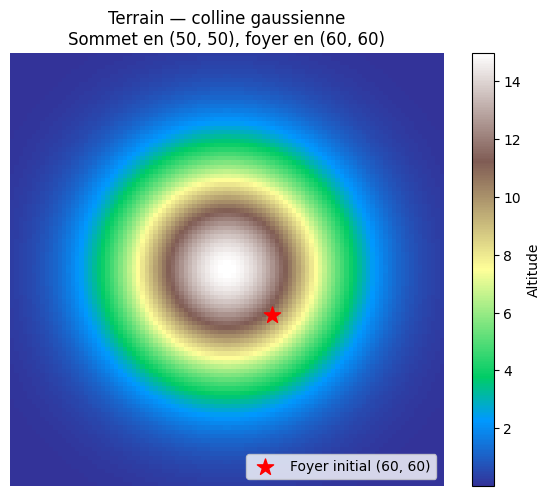

C:\Users\leala\AppData\Local\Temp\ipykernel_15540\3848734480.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


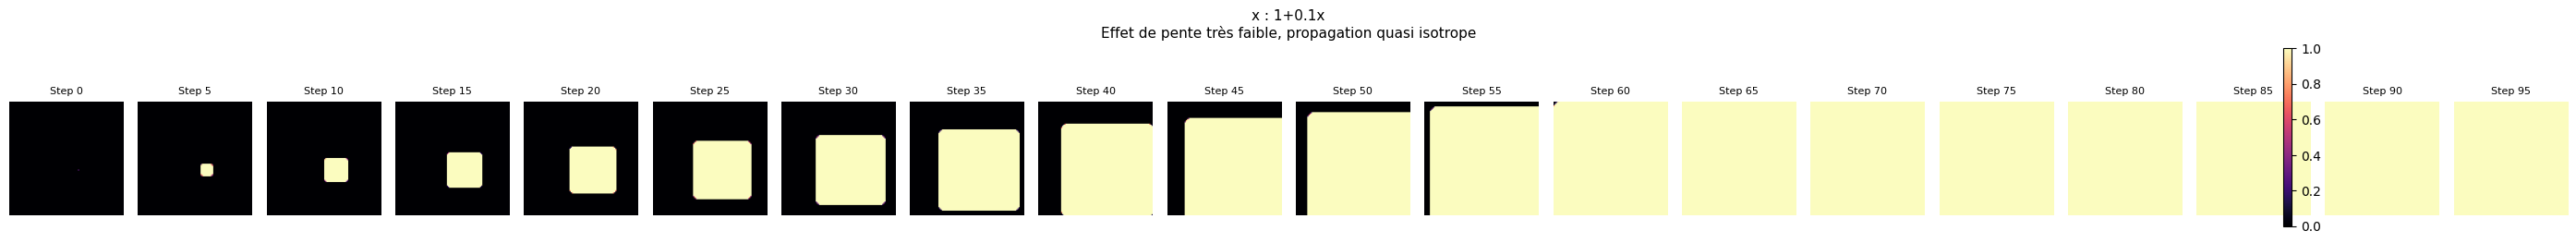

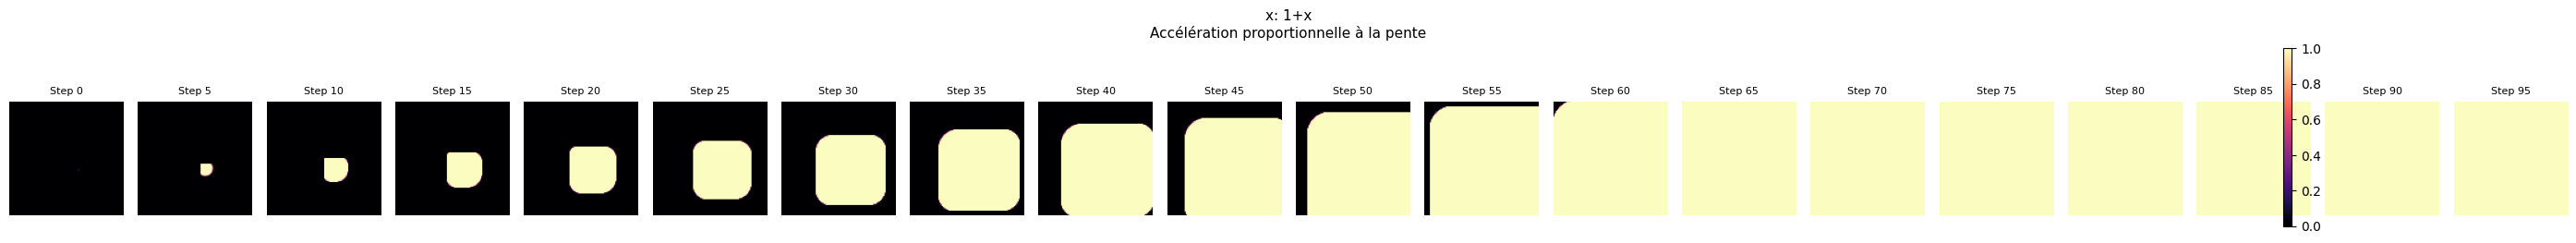

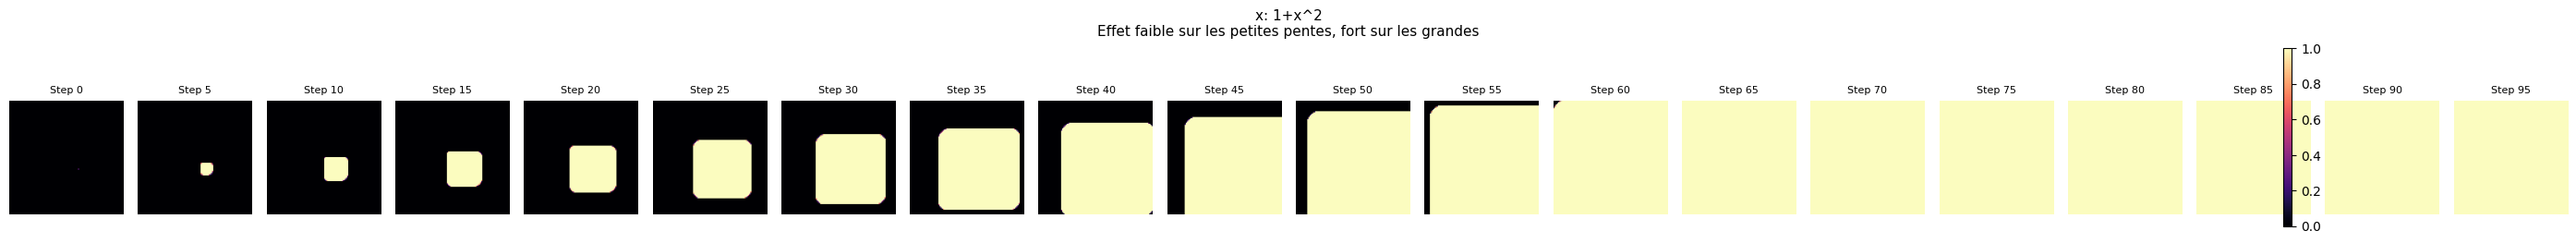

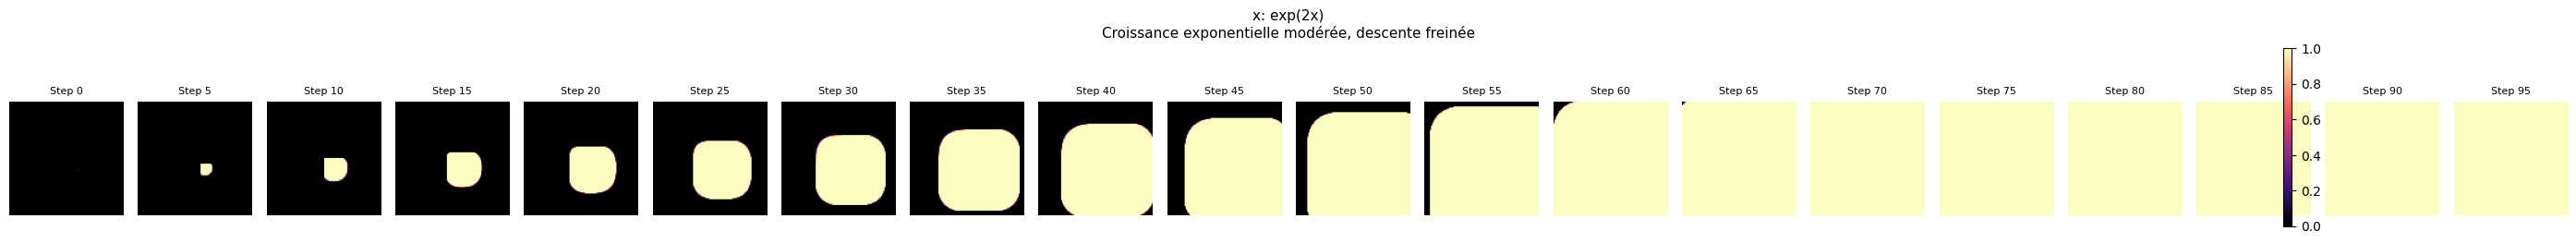

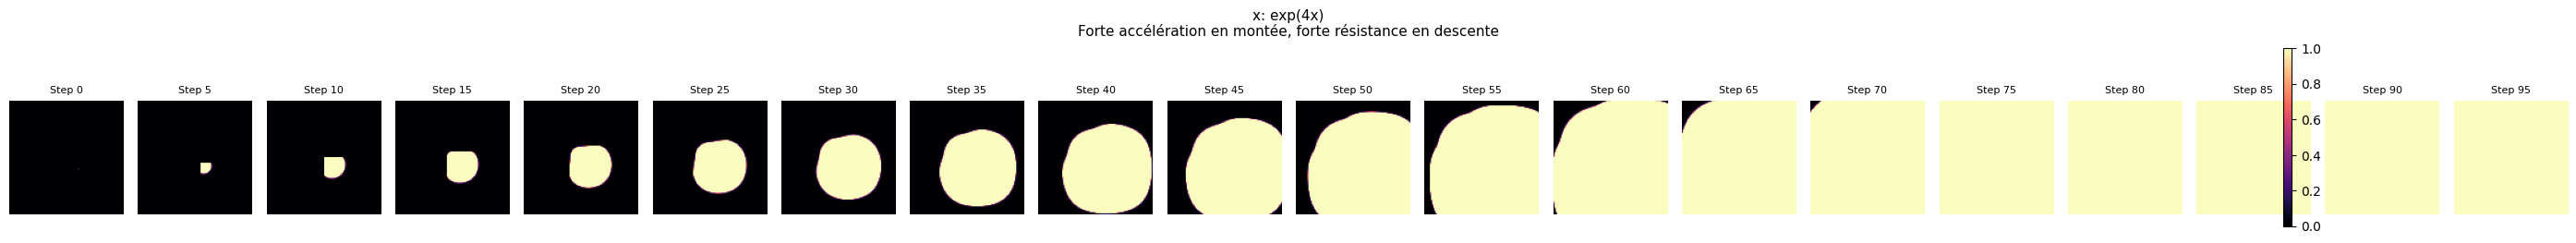

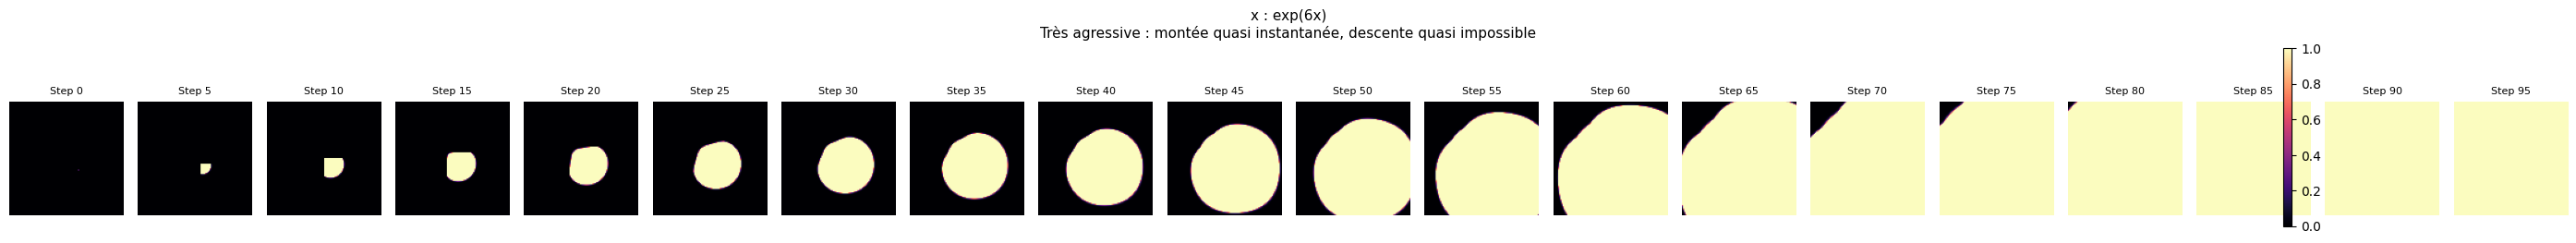

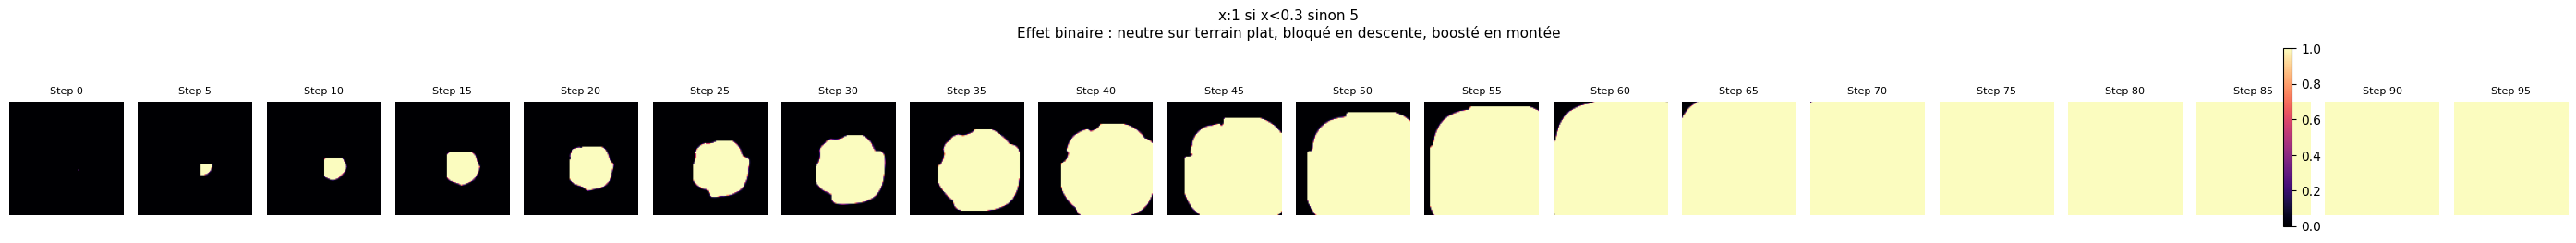

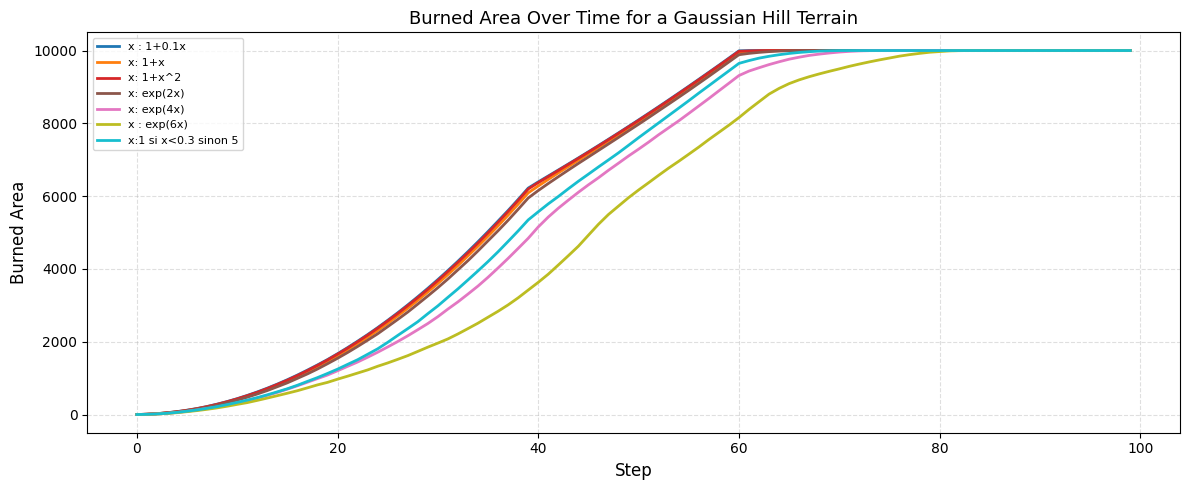

In [12]:
x, y = np.meshgrid(np.linspace(-2, 2, 100), np.linspace(-2, 2, 100))
heights = 15 * np.exp(-(x**2 + y**2))
wind    = np.ones((100, 100))



plt.figure(figsize=(6, 5))
im_terrain = plt.imshow(heights, cmap='terrain', origin='upper')
plt.scatter(60, 60, color='red', s=150, zorder=5, marker='*', label="Foyer initial (60, 60)")
plt.title("Terrain — colline gaussienne\nSommet en (50, 50), foyer en (60, 60)")
plt.colorbar(im_terrain, label="Altitude")
plt.legend(loc="lower right")
plt.axis('off')
plt.tight_layout()
plt.show()

# Parameters

n_steps       = 20
step_interval = 5
total_steps   = n_steps * step_interval  # 80 steps

burned_histories = {}
# Simulation for each height update function
for name, entry in phi_functions.items():
    phi  = entry["fn"]
    desc = entry["desc"]

    CA = CellularAutomaton(100, 100, wind, heights, phi)
    CA.initialize_ignition([(60, 60)], [0.3])

    burned    = []
    plot_idx  = 0
    snapshots = []

    for step in range(total_steps):
        burned.append(np.sum(CA.get_state() > 0.1))
        if step % step_interval == 0 and plot_idx < n_steps:
            snapshots.append((step, CA.get_state().copy()))
            plot_idx += 1
        CA.evolve()

    burned_histories[name] = burned

   
    fig, axes = plt.subplots(1, n_steps, figsize=(28, 2.5))
    for ax, (step, state) in zip(axes, snapshots):
        im = ax.imshow(state, vmin=0, vmax=1, cmap='magma')
        ax.set_title(f"Step {step}", fontsize=8)
        ax.axis('off')

    short_name = name.replace("\n", " — ")
    fig.suptitle(f"{short_name}\n{desc}", fontsize=11, y=1.05)
    plt.colorbar(im, ax=axes.tolist(), fraction=0.02, pad=0.04)
    plt.tight_layout()
    plt.show()

# Aire brûlée
fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(phi_functions)))

for (name, burned), color in zip(burned_histories.items(), colors):
    short_name = name.replace("\n", " — ")
    ax.plot(burned, linewidth=2, color=color, label=short_name)

ax.set_xlabel("Step", fontsize=12)
ax.set_ylabel("Burned Area", fontsize=12)
ax.set_title("Burned Area Over Time for a Gaussian Hill Terrain", fontsize=13)
ax.legend(fontsize=8, loc="upper left")
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

We observe in the propagation, different stages corresponding to the period when the fire rises to the summit, then reaches the summit and then the propagation slows down.

### Impact of the Wind on the fire propagation


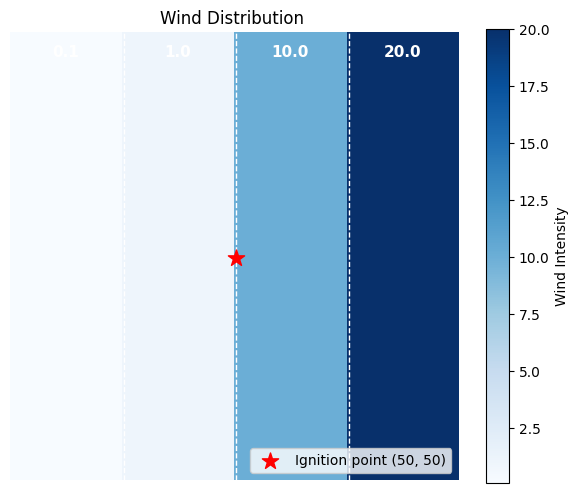

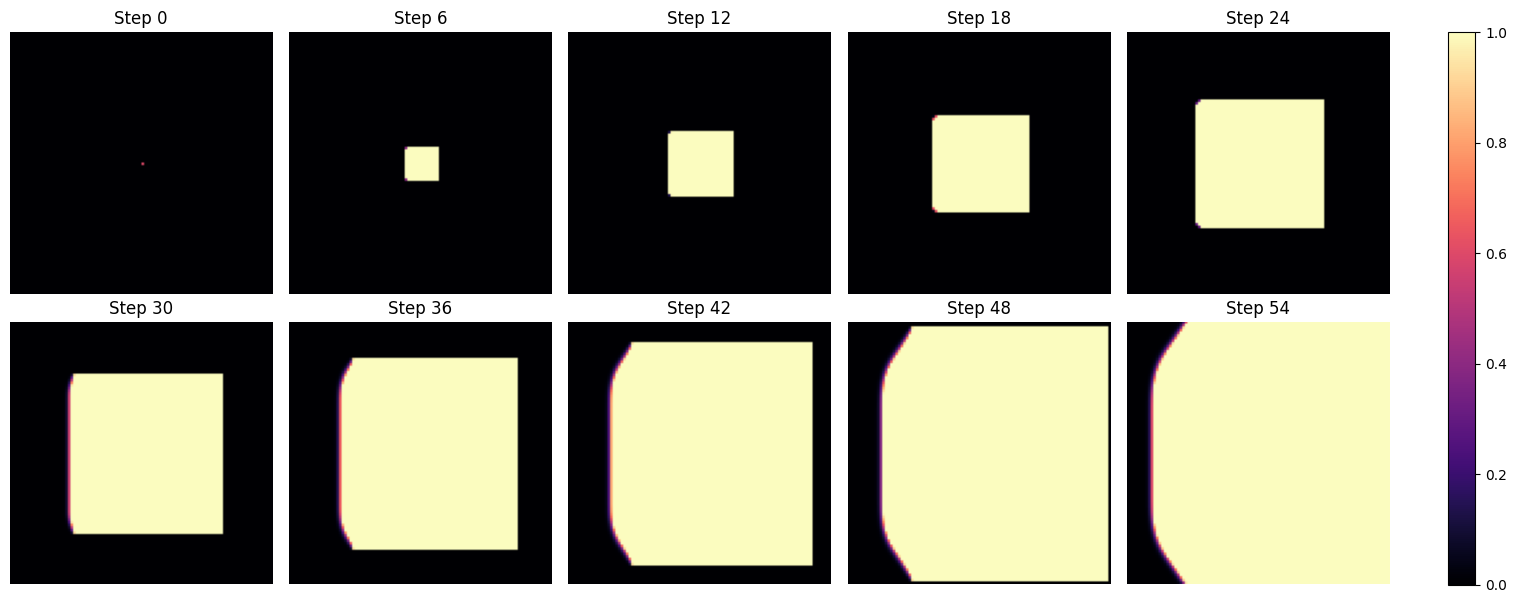

In [4]:
size = 100


# Linear distribution of wind from left to right to test the effect of wind on fire spread 
# The wind increases in discrete steps every 25 columns.

wind = np.hstack([
    0.1 * np.ones((size, 25)), 
    1.0 * np.ones((size, 25)), 
    10.0 * np.ones((size, 25)), 
    20.0 * np.ones((size, 25))  
])
heights = np.zeros((size, size))  # Flat terrain to isolate the effect of wind

plt.figure(figsize=(6, 5))
im_wind = plt.imshow(wind, cmap='Blues', origin='upper')
plt.scatter(50, 50, color='red', s=150, zorder=5, marker='*', label="Ignition point (50, 50)")
plt.axvline(25, color='white', linestyle='--', linewidth=1)
plt.axvline(50, color='white', linestyle='--', linewidth=1)
plt.axvline(75, color='white', linestyle='--', linewidth=1)
plt.text(12, 5, "0.1",  color='white', ha='center', fontsize=11, fontweight='bold')
plt.text(37, 5, "1.0",  color='white', ha='center', fontsize=11, fontweight='bold')
plt.text(62, 5, "10.0", color='white', ha='center', fontsize=11, fontweight='bold')
plt.text(87, 5, "20.0", color='white', ha='center', fontsize=11, fontweight='bold')
plt.title("Wind Distribution ")
plt.colorbar(im_wind, label="Wind Intensity")
plt.legend(loc="lower right")
plt.axis('off')
plt.tight_layout()
plt.show()

CA = CellularAutomaton(size, size, wind, heights, height_update)


CA.initialize_ignition([(50, 50)], [0.6])

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
plot_idx = 0


for step in range(60): 
    if step % 6 == 0 and plot_idx < 10: 
        current_state = CA.get_state()
        im = axes[plot_idx].imshow(current_state, vmin=0, vmax=1, cmap='magma')
        axes[plot_idx].set_title(f"Step {step}")
        axes[plot_idx].axis('off')
        plot_idx += 1

    CA.evolve()

plt.tight_layout()
plt.colorbar(im, ax=axes.ravel().tolist(), fraction=0.02, pad=0.04)
plt.show()

Here, we took a wind that is getting stronger and stronger as we go to the right. Intuitively, the fire should spread more quickly to the right than to the left and this is what we observe in practice.

Now, let’s look at what’s happening, with different types of wind.

In [5]:
# Parameters
size = 100
x_grid, y_grid = np.meshgrid(np.linspace(-1, 1, size), np.linspace(-1, 1, size))
heights = np.zeros((size, size))

In [6]:
# Different functions to test the wind effect on fire spread


def make_wind(name):
    if name == "Bandes croissantes":
        return np.hstack([0.1*np.ones((size,25)), 1.0*np.ones((size,25)),
                          10.0*np.ones((size,25)), 20.0*np.ones((size,25))])

    elif name == "Tourbillon central":
        # Vent proportionnel à la distance au centre, sens horaire
        cx, cy = size//2, size//2
        i_grid, j_grid = np.meshgrid(np.arange(size), np.arange(size), indexing='ij')
        dist = np.sqrt((i_grid - cx)**2 + (j_grid - cy)**2) + 1e-5
        return (dist / dist.max()) * 15

    elif name == "Explosion radiale":
        # Vent maximal au centre, décroît vers les bords
        cx, cy = size//2, size//2
        i_grid, j_grid = np.meshgrid(np.arange(size), np.arange(size), indexing='ij')
        dist = np.sqrt((i_grid - cx)**2 + (j_grid - cy)**2)
        return np.exp(-dist / 15) * 20

    elif name == "Damier":
        # Alternance de zones calmes et venteuses
        wind = np.ones((size, size))
        for i in range(size):
            for j in range(size):
                wind[i, j] = 15.0 if ((i // 20) + (j // 20)) % 2 == 0 else 0.1
        return wind

    elif name == "Couloir central":
        # Vent fort uniquement au centre 
        wind = 0.1 * np.ones((size, size))
        wind[40:60, :] = 15.0
        return wind

    elif name == "Deux foyers de vent":
        # Deux zones de vent fort symétriques
        wind = 0.1 * np.ones((size, size))
        cx1, cx2 = size//4, 3*size//4
        i_grid, j_grid = np.meshgrid(np.arange(size), np.arange(size), indexing='ij')
        for cx in [cx1, cx2]:
            dist = np.sqrt((i_grid - size//2)**2 + (j_grid - cx)**2)
            wind += np.exp(-dist / 10) * 15
        return np.clip(wind, 0, 20)

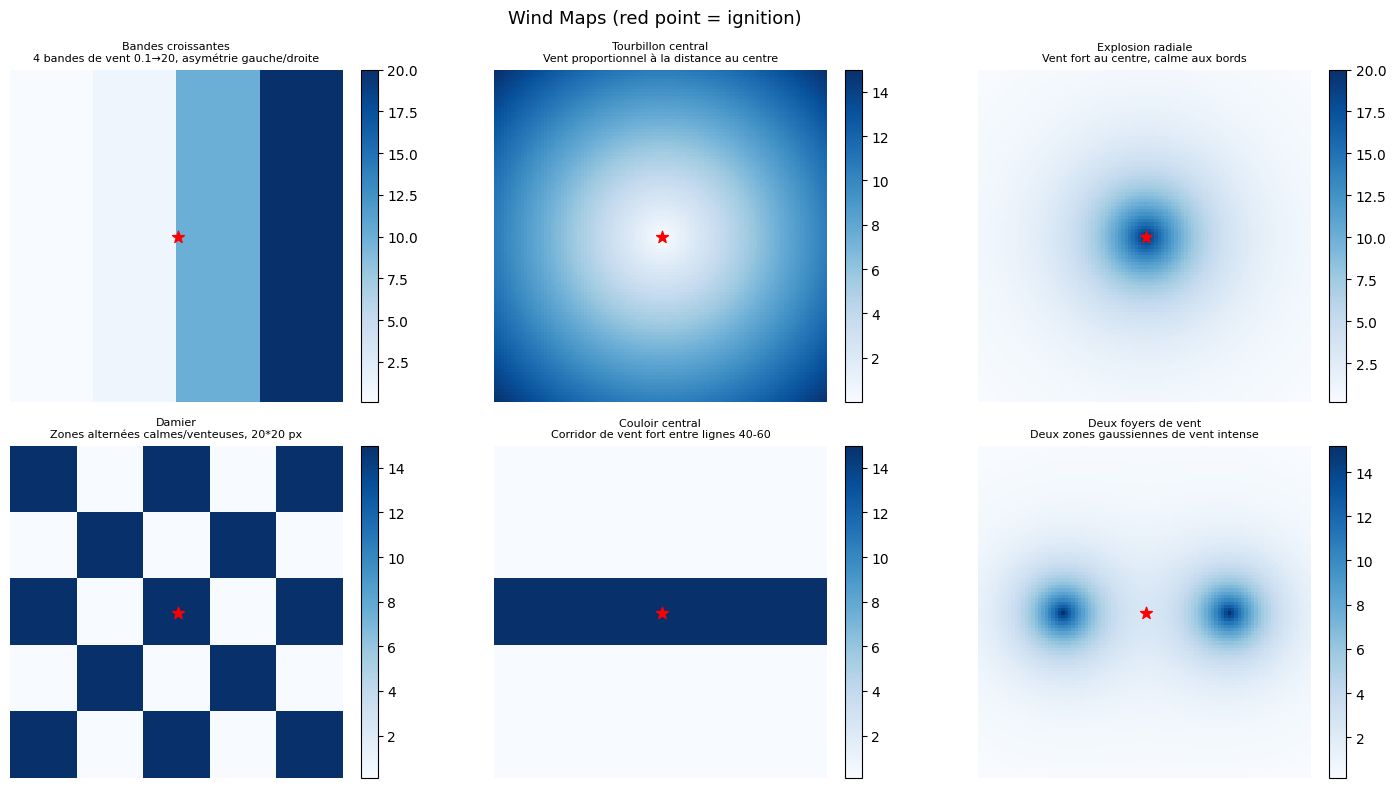

C:\Users\leala\AppData\Local\Temp\ipykernel_26824\2325500032.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


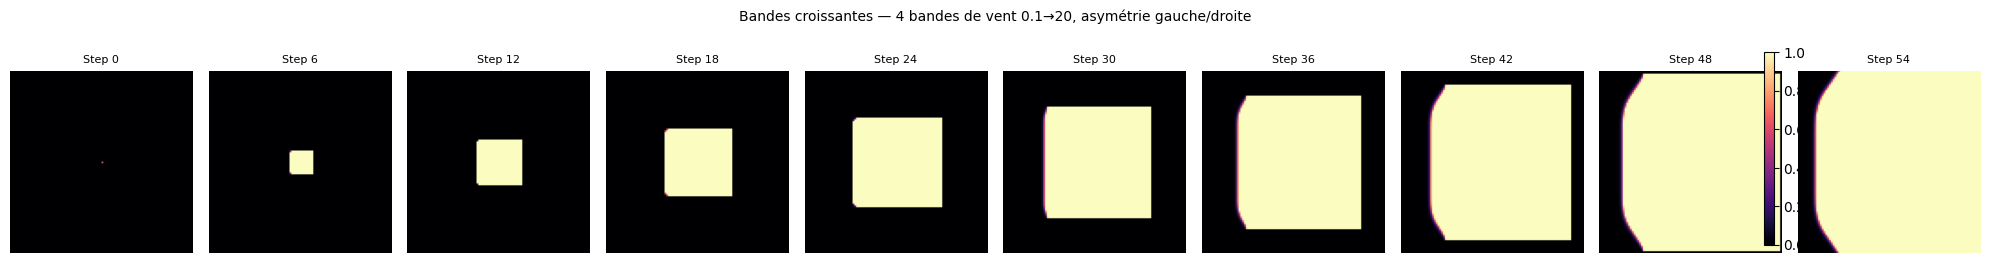

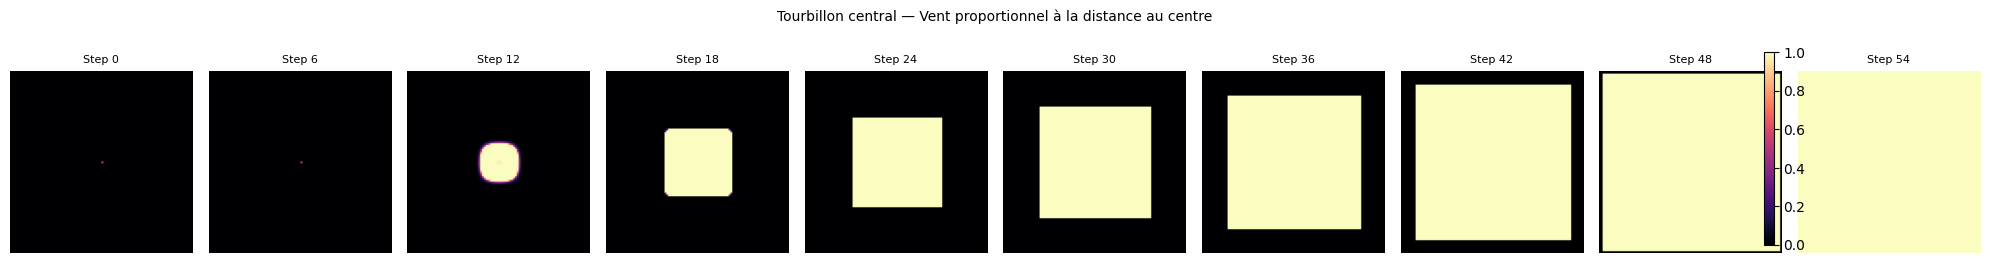

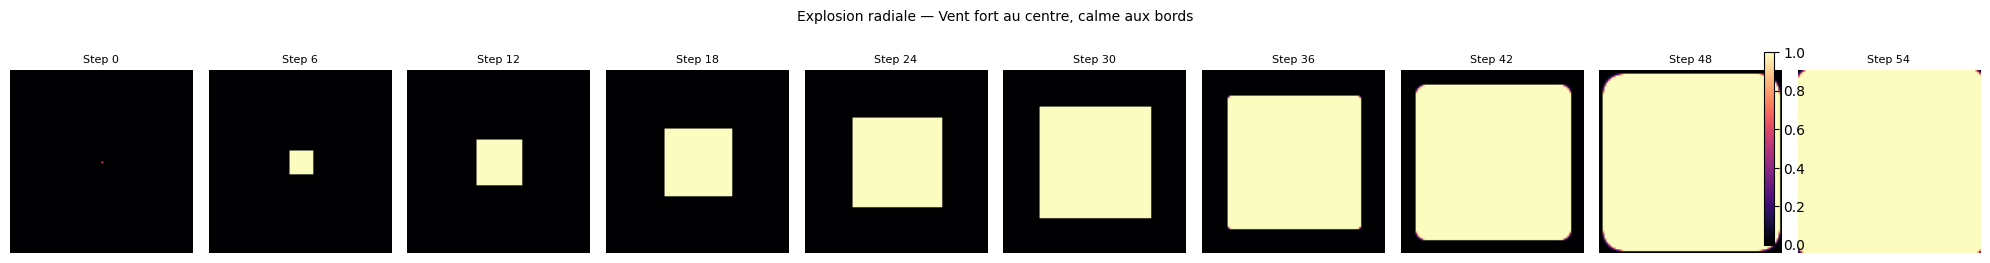

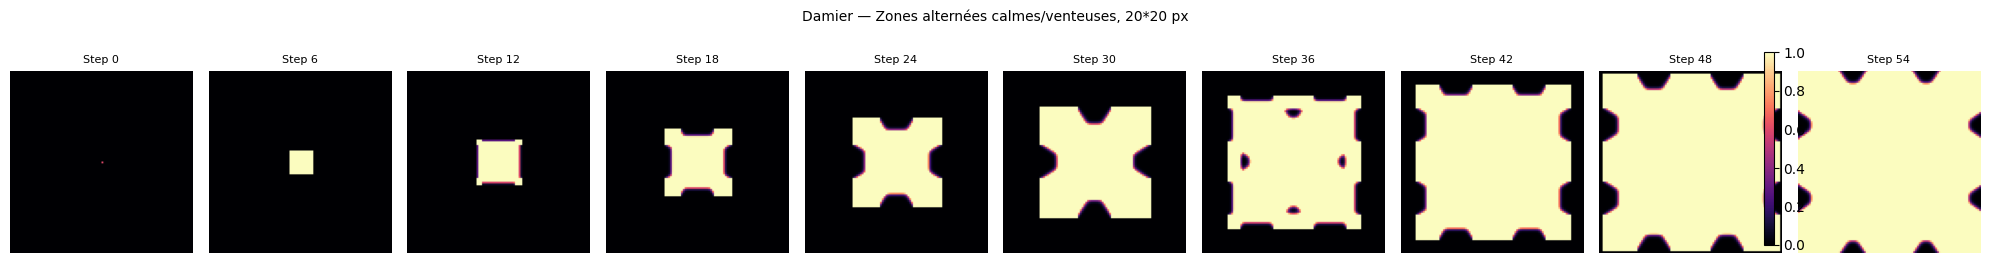

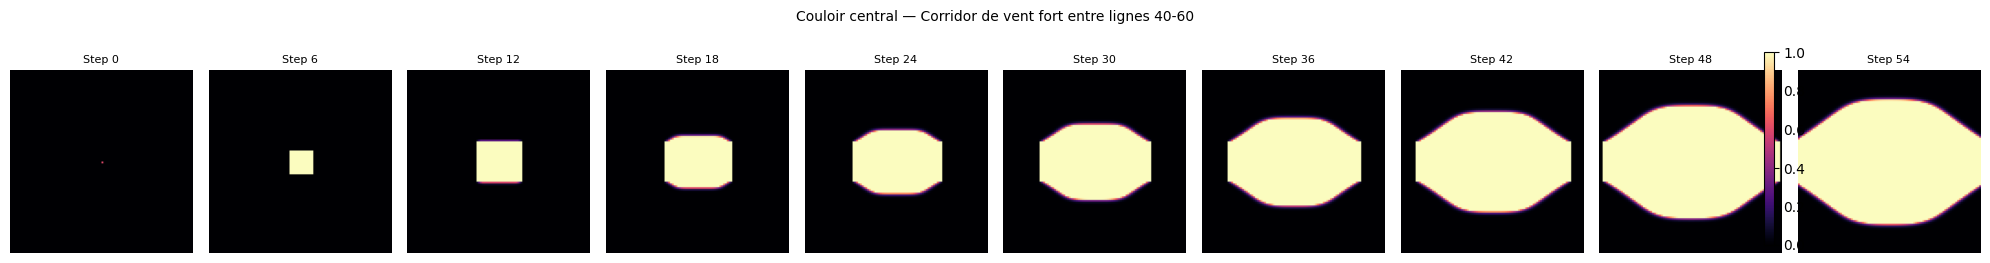

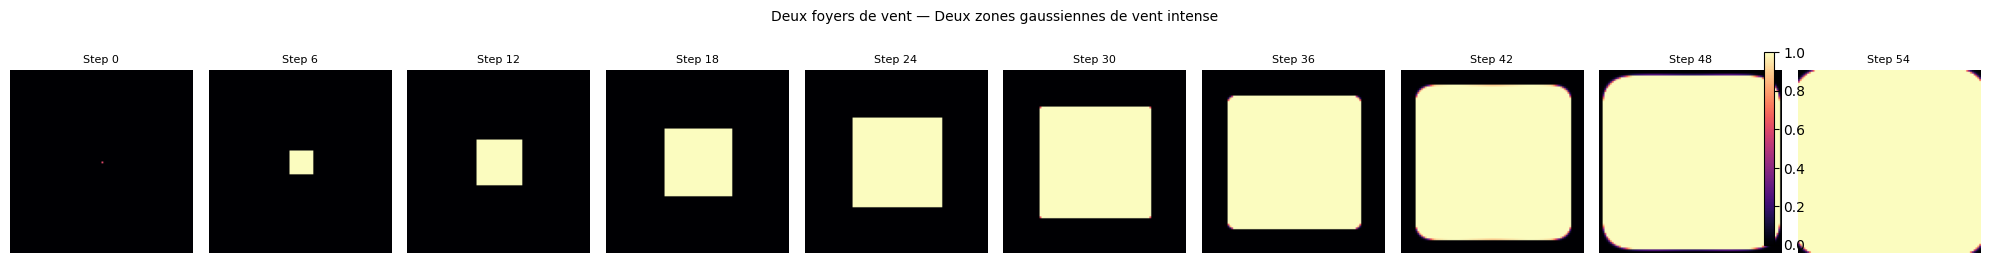

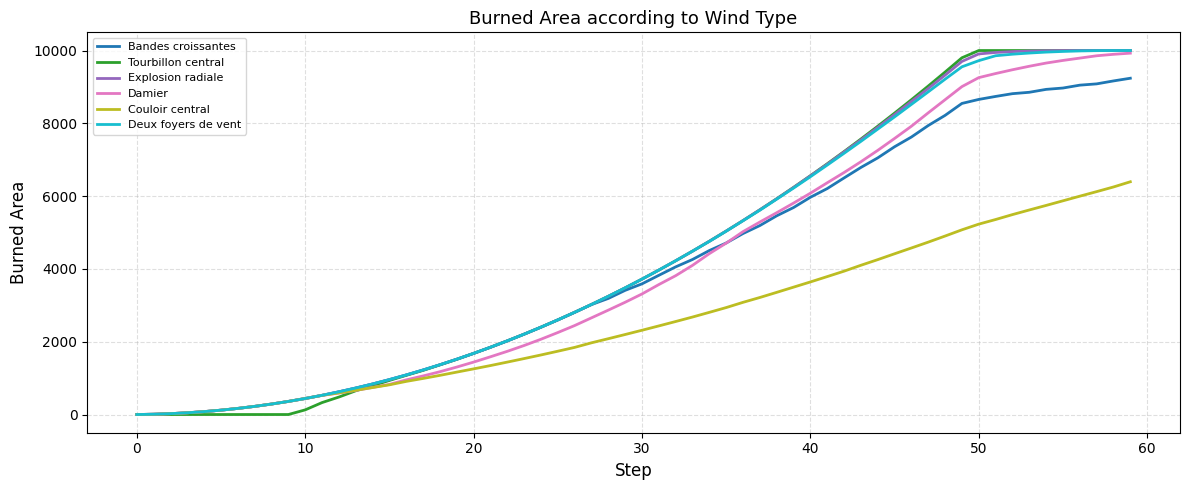

In [9]:
# Simulation
wind_configs = {
    "Bandes croissantes":  {"wind": make_wind("Bandes croissantes"),  "desc": "4 bandes de vent 0.1→20, asymétrie gauche/droite"},
    "Tourbillon central":{"wind": make_wind("Tourbillon central"),"desc": "Vent proportionnel à la distance au centre"},
    "Explosion radiale":   {"wind": make_wind("Explosion radiale"),   "desc": "Vent fort au centre, calme aux bords"},
    "Damier":              {"wind": make_wind("Damier"),              "desc": "Zones alternées calmes/venteuses, 20*20 px"},
    "Couloir central":     {"wind": make_wind("Couloir central"),     "desc": "Corridor de vent fort entre lignes 40-60"},
    "Deux foyers de vent": {"wind": make_wind("Deux foyers de vent"), "desc": "Deux zones gaussiennes de vent intense"},
}

n_steps       = 10
step_interval = 6
total_steps   = n_steps * step_interval

# Print wind maps
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (name, cfg) in zip(axes.flatten(), wind_configs.items()):
    im = ax.imshow(cfg["wind"], cmap='Blues', origin='upper')
    ax.scatter(50, 50, color='red', s=80, zorder=5, marker='*')
    ax.set_title(f"{name}\n{cfg['desc']}", fontsize=8)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.suptitle("Wind Maps (red point = ignition)", fontsize=13)
plt.tight_layout()
plt.show()

# Simulation for each wind configuration
burned_histories = {}

for name, cfg in wind_configs.items():
    wind = cfg["wind"]
    CA = CellularAutomaton(size, size, wind, heights, height_update)
    CA.initialize_ignition([(50, 50)], [0.6])

    burned    = []
    snapshots = []
    plot_idx  = 0

    for step in range(total_steps):
        burned.append(np.sum(CA.get_state() > 0.1))
        if step % step_interval == 0 and plot_idx < n_steps:
            snapshots.append((step, CA.get_state().copy()))
            plot_idx += 1
        CA.evolve()

    burned_histories[name] = burned

    fig, axes = plt.subplots(1, n_steps, figsize=(20, 2.5))
    for ax, (step, state) in zip(axes, snapshots):
        im = ax.imshow(state, vmin=0, vmax=1, cmap='magma')
        ax.set_title(f"Step {step}", fontsize=8)
        ax.axis('off')
    fig.suptitle(f"{name} — {cfg['desc']}", fontsize=10, y=1.05)
    plt.colorbar(im, ax=axes.tolist(), fraction=0.02, pad=0.04)
    plt.tight_layout()
    plt.show()

# Burned area comparison
fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(wind_configs)))
for (name, burned), color in zip(burned_histories.items(), colors):
    ax.plot(burned, linewidth=2, color=color, label=name)
ax.set_xlabel("Step", fontsize=12)
ax.set_ylabel("Burned Area", fontsize=12)
ax.set_title("Burned Area according to Wind Type", fontsize=13)
ax.legend(fontsize=8, loc="upper left")
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()